In [1]:
#Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Import graph plotting libraries
import seaborn as sns
%matplotlib inline
sns.set(style="ticks")

### Read the input file 'Diabetes.csv' using Pandas and check it's column names(1 Marks)

In [2]:
df = pd.read_csv("diabetes.csv")

In [3]:
# Eye ball the imported dataset

In [4]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
Pregnancies                 768 non-null int64
Glucose                     768 non-null int64
BloodPressure               768 non-null int64
SkinThickness               768 non-null int64
Insulin                     768 non-null int64
BMI                         768 non-null float64
DiabetesPedigreeFunction    768 non-null float64
Age                         768 non-null int64
Outcome                     768 non-null int64
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### Check dimension of dataset

In [7]:
df.shape

(768, 9)

### Check distribution of dependent variable, Outcome and plot it (1 Marks)

In [8]:
df.groupby(["Outcome"]).count()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,500,500,500,500,500,500,500,500
1,268,268,268,268,268,268,268,268


In [9]:
x = df['Outcome'].value_counts()
x

0    500
1    268
Name: Outcome, dtype: int64

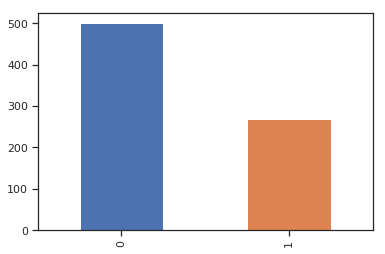

In [10]:
x.plot.bar()

### Inference
#### Out of  768 data points, 500 are labeled as 0 and 268 as 1.
#### Outcome 0 means No diabetes, outcome 1 means diabetes

In [11]:
# Check data types and info of dataset

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
Pregnancies                 768 non-null int64
Glucose                     768 non-null int64
BloodPressure               768 non-null int64
SkinThickness               768 non-null int64
Insulin                     768 non-null int64
BMI                         768 non-null float64
DiabetesPedigreeFunction    768 non-null float64
Age                         768 non-null int64
Outcome                     768 non-null int64
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [13]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

### Check data distribution using summary statistics and provide your findings(2 Marks)

In [14]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [15]:
fields = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
for field in fields :
    print('field %s : num 0-entries: %d' % (field, len(df.loc[ df[field] == 0, field ])))

field Glucose : num 0-entries: 5
field BloodPressure : num 0-entries: 35
field SkinThickness : num 0-entries: 227
field Insulin : num 0-entries: 374
field BMI : num 0-entries: 11


In [16]:
def replace_zero_field(data, field):
    nonzero_vals = data.loc[data[field] != 0, field]
    avg = nonzero_vals.median()
    length = len(data.loc[ data[field] == 0, field])   # num of 0-entries
    data.loc[ data[field] == 0, field ] = avg
    print('Field: %s; fixed %d entries with value: %.3f' % (field,length, avg))

for field in fields :
    replace_zero_field(df,field)
print()
for field in fields :
    print('Field %s : num 0-entries: %d' % (field, len(df.loc[ df[field] == 0, field ])))

Field: Glucose; fixed 5 entries with value: 117.000
Field: BloodPressure; fixed 35 entries with value: 72.000
Field: SkinThickness; fixed 227 entries with value: 29.000
Field: Insulin; fixed 374 entries with value: 125.000
Field: BMI; fixed 11 entries with value: 32.300

Field Glucose : num 0-entries: 0
Field BloodPressure : num 0-entries: 0
Field SkinThickness : num 0-entries: 0
Field Insulin : num 0-entries: 0
Field BMI : num 0-entries: 0


### Do correlation analysis and bivariate viualization with Insights(1 Marks)

/usr/lib/python3/dist-packages/statsmodels/nonparametric/kde.py:494: RuntimeWarning: invalid value encountered in true_divide
  binned = fast_linbin(X,a,b,gridsize)/(delta*nobs)
/usr/lib/python3/dist-packages/statsmodels/nonparametric/kdetools.py:34: RuntimeWarning: invalid value encountered in double_scalars
  FAC1 = 2*(np.pi*bw/RANGE)**2


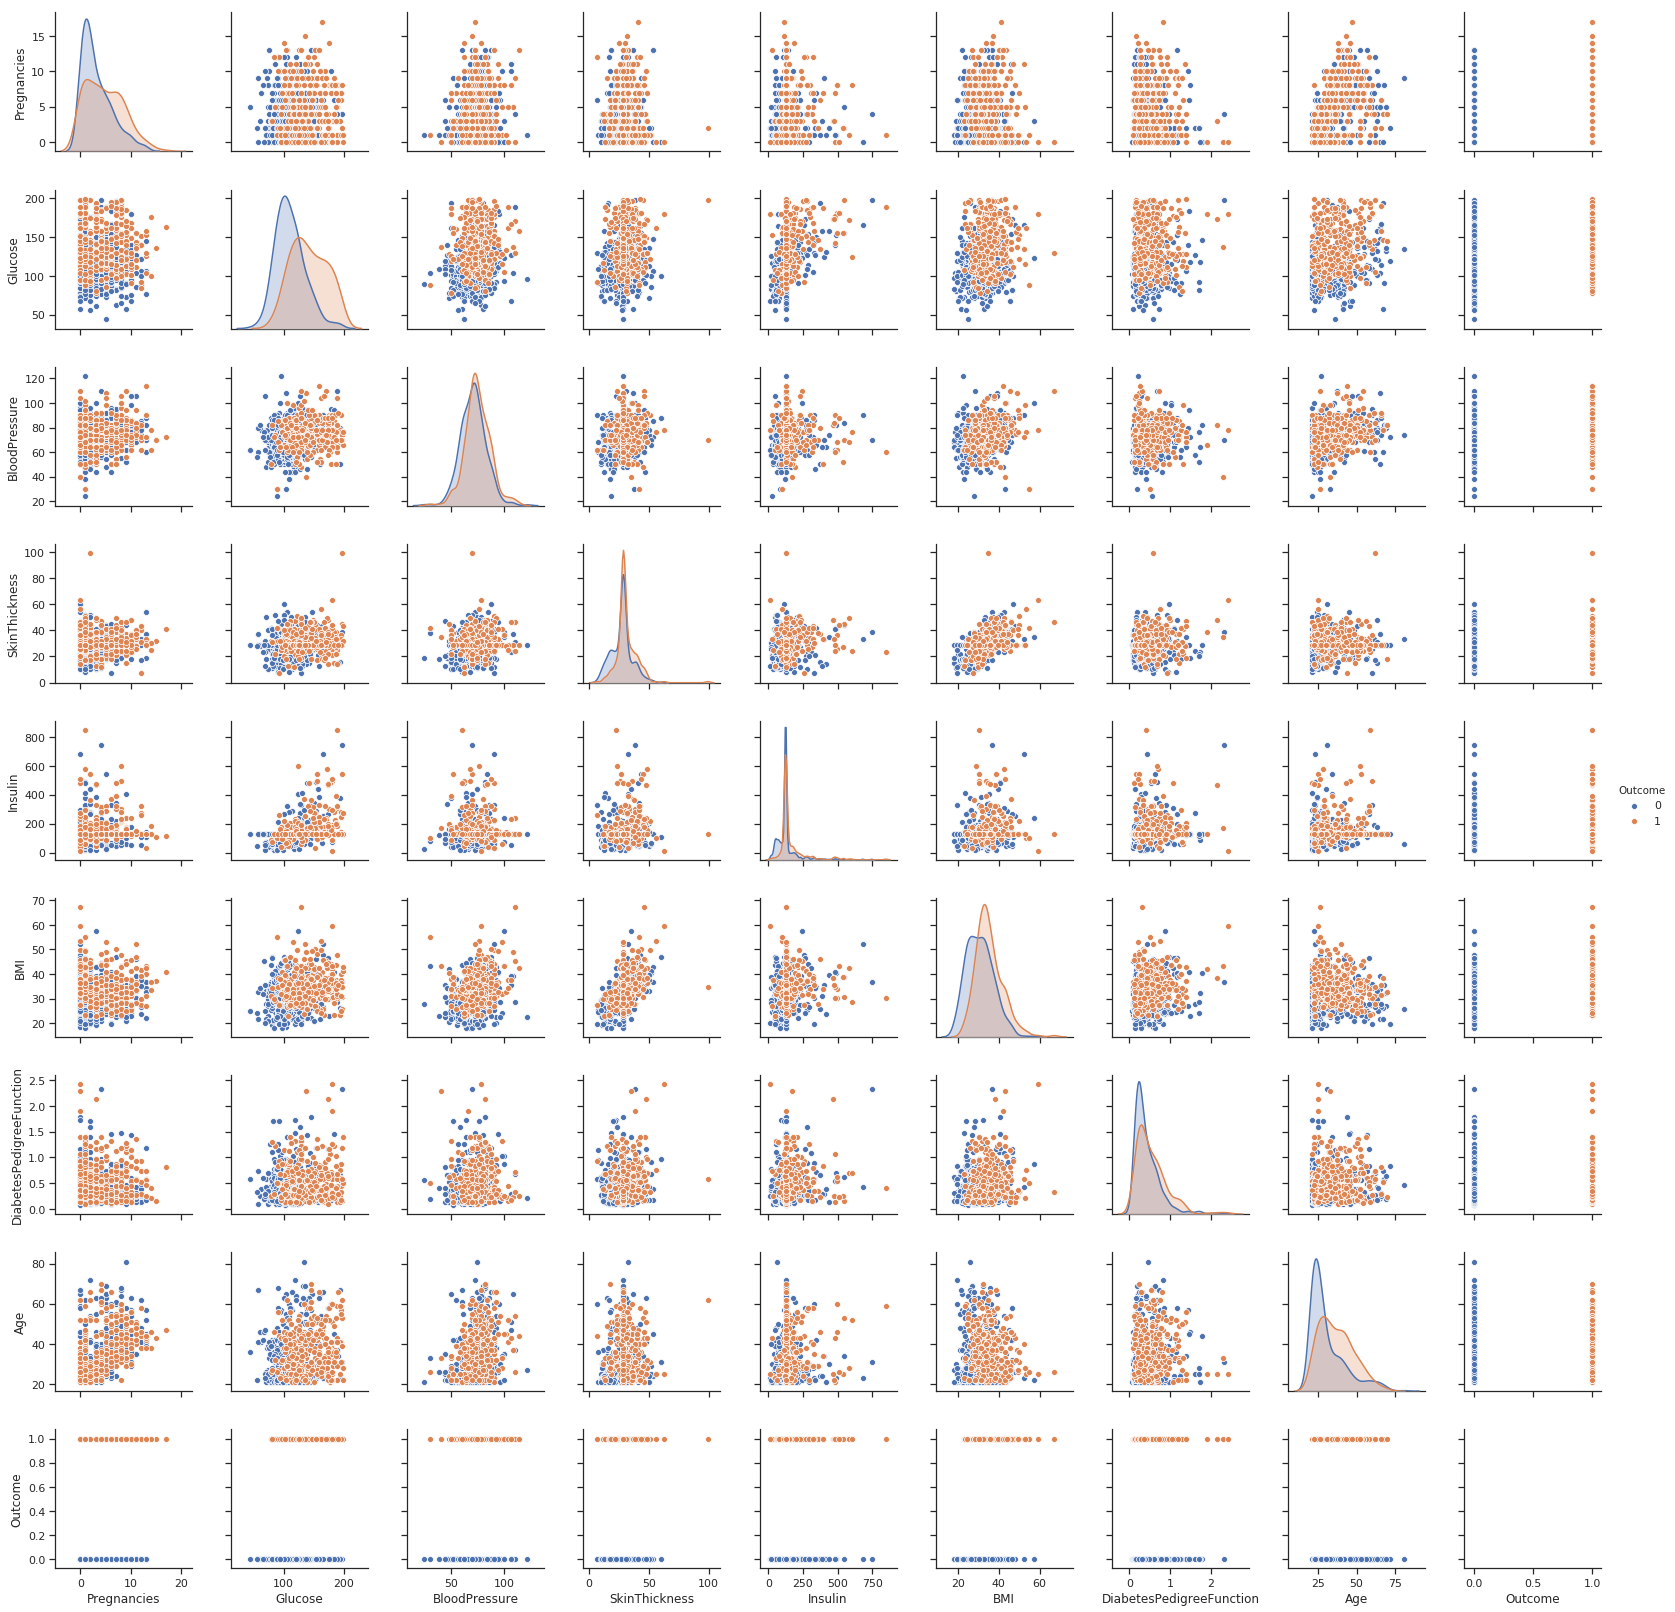

In [17]:
sns.pairplot(df, diag_kind='kde', hue='Outcome')

### Inference
The data is normally distributed, 

There are few outliers, which needed cleanup

All the zeros in the field is cleaned up

#### Do train and test split with stratify sampling on Outcome variable to maintain the distribution of dependent variable(1 Marks)

In [81]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score

In [22]:
X =  df.drop(["Outcome"], axis=1)
y =  df.pop("Outcome")

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((537, 8), (231, 8), (537,), (231,))

In [44]:
from mlxtend.plotting import plot_decision_regions

def plot_boundary(svc, prediction):
    value=1.5
    width=0.75

    # Plot Decision Region using mlxtend's awesome plotting function
    plot_decision_regions(X=X[0].values, 
                      y=y[0].values,
                      clf=svc, 
                      legend=2)#,
                      #feature_index=[0,1],                        #these one will be plotted  
                      #filler_feature_values={2:value, 3:value, 4:value, 5:value, 6:value, 7:value },  #these will be ignored
                      #filler_feature_ranges={2:width, 3:width, 4:width, 5:width, 6:width, 7:width})
                      
                         
    # Update plot object with X/Y axis labels and Figure Title
    plt.xlabel(X.columns[0], size=14)
    plt.ylabel(X.columns[1], size=14)
    plt.title('SVM Decision Region Boundary', size=16)
    plt.show()

In [97]:
def analyze_model_parameters(model, x_tr=X_train, x_te=X_test):
    preds = model.predict(x_te)
    print("Train Model score = ", model.score(x_tr, y_train))
    print("Test Model score = ", model.score(x_te, y_test))
    print("Confusion Matrix:\n",confusion_matrix(preds, y_test))
    print("F1-Score: ", f1_score(y_test, preds))
    print("Accuracy Score:", accuracy_score(y_test, preds))

### Train Support Vector Machine Model(1 Marks)

In [47]:
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
# To calculate the accuracy score of the model
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import make_scorer, roc_auc_score
from scipy import stats

In [48]:
# Building a Support Vector Machine on train data
svc_model_lin = SVC(C= .1, kernel='linear', gamma= 1)
svc_model_lin.fit(X_train, y_train)

SVC(C=0.1, cache_size=200, class_weight=None, coef0=0.0,
  decision_function_shape='ovr', degree=3, gamma=1, kernel='linear',
  max_iter=-1, probability=False, random_state=None, shrinking=True,
  tol=0.001, verbose=False)

In [49]:
x_min, x_max = np.array(X)[:, 0].min() - 1, np.array(X)[:, 0].max() + 1
y_min, y_max = np.array(X)[:, 1].min() - 1, np.array(X)[:, 1].max() + 1

In [51]:
#plot_boundary(svc_model_lin, prediction)

In [98]:
#Evaluate model parameters like accuracy and score
analyze_model_parameters(svc_model_lin, X_train, X_test)

Train Model score =  0.7672253258845437
Test Model score =  0.7705627705627706
Confusion Matrix:
 [[142  38]
 [ 15  36]]
F1-Score:  0.5760000000000001
Accuracy Score: 0.7705627705627706


In [54]:
# DEFINE MODEL AND PERFORMANCE MEASURE
mdl = SVC(probability = True, random_state = 1)
auc = make_scorer(roc_auc_score)
# RANDOM SEARCH FOR 20 COMBINATIONS OF PARAMETERS
rand_list = {"C": stats.uniform(2, 10),
             "gamma": stats.uniform(0.1, 1)}

rand_search = RandomizedSearchCV(mdl, param_distributions = rand_list, n_iter = 20, n_jobs = -1, cv = 3, random_state = 0, scoring = auc) 
rand_search.fit(X_train, y_train) 
rand_search.cv_results_

/home/siju/.local/lib/python3.6/site-packages/sklearn/utils/deprecation.py:125: FutureWarning: You are accessing a training score ('split0_train_score'), which will not be available by default any more in 0.21. If you need training scores, please set return_train_score=True
  warnings.warn(*warn_args, **warn_kwargs)
/home/siju/.local/lib/python3.6/site-packages/sklearn/utils/deprecation.py:125: FutureWarning: You are accessing a training score ('split1_train_score'), which will not be available by default any more in 0.21. If you need training scores, please set return_train_score=True
  warnings.warn(*warn_args, **warn_kwargs)
/home/siju/.local/lib/python3.6/site-packages/sklearn/utils/deprecation.py:125: FutureWarning: You are accessing a training score ('split2_train_score'), which will not be available by default any more in 0.21. If you need training scores, please set return_train_score=True
  warnings.warn(*warn_args, **warn_kwargs)
/home/siju/.local/lib/python3.6/site-packages/

{'mean_fit_time': array([0.06051318, 0.05904651, 0.05813281, 0.05567662, 0.06762727,
        0.05692728, 0.04897332, 0.05271912, 0.04680872, 0.04742241,
        0.04871631, 0.04861554, 0.0491569 , 0.04648121, 0.05085874,
        0.04800471, 0.04872497, 0.04868897, 0.04778298, 0.03275832]),
 'std_fit_time': array([3.63833214e-03, 1.20830632e-03, 2.24166075e-03, 2.16634565e-03,
        7.13747132e-03, 2.92852316e-03, 8.98550251e-05, 3.74997335e-04,
        9.38083059e-04, 2.11137553e-03, 2.40808228e-03, 1.45966671e-03,
        9.71467623e-04, 1.67176454e-03, 9.94903924e-04, 1.19816189e-03,
        1.14347288e-03, 1.45161932e-03, 4.23126775e-03, 1.02780501e-04]),
 'mean_score_time': array([0.00549197, 0.00582846, 0.00591286, 0.00503016, 0.00531761,
        0.00467722, 0.00447679, 0.00483998, 0.00443769, 0.0054698 ,
        0.00442799, 0.0043985 , 0.00460776, 0.0043637 , 0.00422875,
        0.00433612, 0.00468882, 0.00445406, 0.00283535, 0.00268666]),
 'std_score_time': array([4.50490291e-

In [99]:
#Evaluate model parameters like accuracy and score
analyze_model_parameters(rand_search, X_train, X_test)

Train Model score =  1.0
Test Model score =  0.5
Confusion Matrix:
 [[157  74]
 [  0   0]]
F1-Score:  0.0
Accuracy Score: 0.6796536796536796


/home/siju/.local/lib/python3.6/site-packages/sklearn/metrics/classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)


In [57]:
# GRID SEARCH FOR 20 COMBINATIONS OF PARAMETERS
grid_list = {"C": np.arange(2, 10, 2),
             "gamma": np.arange(0.1, 1, 0.2),
             "kernel": ['linear', 'rbf']}
grid_search = GridSearchCV(mdl, param_grid = grid_list, n_jobs = -1, cv = 3, scoring = auc) 
grid_search.fit(X_train, y_train) 
grid_search.cv_results_

/home/siju/.local/lib/python3.6/site-packages/sklearn/utils/deprecation.py:125: FutureWarning: You are accessing a training score ('split0_train_score'), which will not be available by default any more in 0.21. If you need training scores, please set return_train_score=True
  warnings.warn(*warn_args, **warn_kwargs)
/home/siju/.local/lib/python3.6/site-packages/sklearn/utils/deprecation.py:125: FutureWarning: You are accessing a training score ('split1_train_score'), which will not be available by default any more in 0.21. If you need training scores, please set return_train_score=True
  warnings.warn(*warn_args, **warn_kwargs)
/home/siju/.local/lib/python3.6/site-packages/sklearn/utils/deprecation.py:125: FutureWarning: You are accessing a training score ('split2_train_score'), which will not be available by default any more in 0.21. If you need training scores, please set return_train_score=True
  warnings.warn(*warn_args, **warn_kwargs)
/home/siju/.local/lib/python3.6/site-packages/

{'mean_fit_time': array([1.67554038e+01, 5.13443947e-02, 1.70169890e+01, 5.53938548e-02,
        1.68703218e+01, 4.99680837e-02, 1.68007755e+01, 5.76616128e-02,
        1.69187644e+01, 5.24946849e-02, 3.85205132e+01, 6.15379810e-02,
        3.85359924e+01, 5.78204791e-02, 3.73926660e+01, 5.23704688e-02,
        3.94746865e+01, 6.71540896e-02, 3.90782611e+01, 6.59833749e-02,
        5.09335507e+01, 5.87704182e-02, 5.29229556e+01, 6.40764236e-02,
        4.69535990e+01, 4.61033980e-02, 5.27034078e+01, 6.02622827e-02,
        4.44417237e+01, 4.91574605e-02, 5.96703471e+01, 5.89198271e-02,
        4.35985307e+01, 6.09575113e-02, 5.67858394e+01, 5.49146334e-02,
        3.47682257e+01, 4.93872960e-02, 4.48425332e+01, 3.04749807e-02]),
 'std_fit_time': array([1.18589327e+00, 1.97917581e-03, 1.24679600e+00, 1.63144663e-03,
        1.37582574e+00, 9.44649379e-04, 8.72232272e-01, 9.29778461e-03,
        7.06522295e-01, 2.07691242e-03, 5.53078776e+00, 7.10521297e-03,
        4.02467504e+00, 3.644

In [61]:
# your insights

In [100]:
#Evaluate model parameters like accuracy and score
analyze_model_parameters(grid_search, X_train, X_test)

Train Model score =  0.7293363589913139
Test Model score =  0.6922878292305044
Confusion Matrix:
 [[141  38]
 [ 16  36]]
F1-Score:  0.5714285714285714
Accuracy Score: 0.7662337662337663


In [59]:
grid_search.best_estimator_

SVC(C=2, cache_size=200, class_weight=None, coef0=0.0,
  decision_function_shape='ovr', degree=3, gamma=0.1, kernel='linear',
  max_iter=-1, probability=True, random_state=1, shrinking=True, tol=0.001,
  verbose=False)

In [60]:
grid_search.best_score_ 

0.7146464032782235

As the C value increases the accuracy increases.

### Scale the data points using MinMaxScaler ( 1 Marks)

In [62]:
from sklearn.preprocessing import MinMaxScaler

In [63]:
scaler = MinMaxScaler(feature_range=(0, 1))

### Fit SVM Model on Scale data and give your observation( 1 Marks)

In [64]:
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.fit_transform(X_test)

/home/siju/.local/lib/python3.6/site-packages/sklearn/preprocessing/data.py:323: DataConversionWarning: Data with input dtype int64, float64 were all converted to float64 by MinMaxScaler.
  return self.partial_fit(X, y)
/home/siju/.local/lib/python3.6/site-packages/sklearn/preprocessing/data.py:323: DataConversionWarning: Data with input dtype int64, float64 were all converted to float64 by MinMaxScaler.
  return self.partial_fit(X, y)


In [67]:
X_train_std = pd.DataFrame(X_train_std, columns=df.columns)
X_test_std = pd.DataFrame(X_test_std, columns=df.columns)

#we can try increasing either C or gamma to fit a more complex model.

### Try improving the model accuracy using C=1000 (1 Marks)

In [70]:
# Building a Support Vector Machine on train data
svc_model = SVC(C=1000, kernel='linear', gamma= 1)
svc_model.fit(X_train_std, y_train)

SVC(C=1000, cache_size=200, class_weight=None, coef0=0.0,
  decision_function_shape='ovr', degree=3, gamma=1, kernel='linear',
  max_iter=-1, probability=False, random_state=None, shrinking=True,
  tol=0.001, verbose=False)

In [101]:
#Evaluate model parameters like accuracy and score
analyze_model_parameters(svc_model, X_train_std, X_test_std)

Train Model score =  0.7690875232774674
Test Model score =  0.7489177489177489
Confusion Matrix:
 [[126  27]
 [ 31  47]]
F1-Score:  0.6184210526315789
Accuracy Score: 0.7489177489177489


### Inference
#### Large Value of parameter C => small margin
#### Small Value of paramerter C => Large margin

The C parameter tells the SVM optimization how much you want to avoid misclassifying each training example. For large values of C, the optimization will choose a smaller-margin hyperplane if that hyperplane does a better job of getting all the training points classified correctly. Conversely, a very small value of C will cause the optimizer to look for a larger-margin separating hyperplane, even if that hyperplane misclassifies more points. For very tiny values of C, you should get misclassified examples, often even if your training data is linearly separable

### Here, increasing C allows us to improve the model, resulting in ??? accuracy.
### Let's try to explore different Kernel and C (Bonus for practice)

In [72]:
import multiprocessing 
from sklearn.model_selection import GridSearchCV

In [73]:
 param_grid = [    {        
     'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],        
     'C': [ 0.1, 0.2, 0.4, 0.5, 1.0, 1.5, 1.8, 2.0, 2.5, 3.0 ]    } ]

In [74]:
gs = GridSearchCV(estimator=SVC(), param_grid=param_grid,scoring='accuracy', cv=10, n_jobs=multiprocessing.cpu_count())

In [75]:
gs.fit(X_train_std, y_train) 

/home/siju/.local/lib/python3.6/site-packages/sklearn/model_selection/_search.py:841: DeprecationWarning: The default of the `iid` parameter will change from True to False in version 0.22 and will be removed in 0.24. This will change numeric results when test-set sizes are unequal.
  DeprecationWarning)
/home/siju/.local/lib/python3.6/site-packages/sklearn/svm/base.py:196: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
  "avoid this warning.", FutureWarning)


GridSearchCV(cv=10, error_score='raise-deprecating',
       estimator=SVC(C=1.0, cache_size=200, class_weight=None, coef0=0.0,
  decision_function_shape='ovr', degree=3, gamma='auto_deprecated',
  kernel='rbf', max_iter=-1, probability=False, random_state=None,
  shrinking=True, tol=0.001, verbose=False),
       fit_params=None, iid='warn', n_jobs=12,
       param_grid=[{'kernel': ['linear', 'rbf', 'poly', 'sigmoid'], 'C': [0.1, 0.2, 0.4, 0.5, 1.0, 1.5, 1.8, 2.0, 2.5, 3.0]}],
       pre_dispatch='2*n_jobs', refit=True, return_train_score='warn',
       scoring='accuracy', verbose=0)

In [76]:
gs.best_estimator_

SVC(C=1.5, cache_size=200, class_weight=None, coef0=0.0,
  decision_function_shape='ovr', degree=3, gamma='auto_deprecated',
  kernel='rbf', max_iter=-1, probability=False, random_state=None,
  shrinking=True, tol=0.001, verbose=False)

In [77]:
gs.best_score_ 

0.7653631284916201

In [102]:
#Evaluate model parameters like accuracy and score
analyze_model_parameters(gs, X_train_std, X_test_std)

Train Model score =  0.7672253258845437
Test Model score =  0.7359307359307359
Confusion Matrix:
 [[121  25]
 [ 36  49]]
F1-Score:  0.6163522012578617
Accuracy Score: 0.7359307359307359
